In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [34]:
df=sns.load_dataset('tips')

In [35]:
print(df.info())
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB
None


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [36]:
df['sex'].value_counts()


sex
Male      157
Female     87
Name: count, dtype: int64

In [37]:
df['smoker'].value_counts()

smoker
No     151
Yes     93
Name: count, dtype: int64

In [38]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [39]:
df['time'].value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [40]:
df['size'].value_counts()

size
2    156
3     38
4     37
5      5
1      4
6      4
Name: count, dtype: int64

In [41]:
X=df[['tip', 'sex', 'smoker', 'day', 'time', 'size']]
y=df['total_bill']
X,y

(      tip     sex smoker   day    time  size
 0    1.01  Female     No   Sun  Dinner     2
 1    1.66    Male     No   Sun  Dinner     3
 2    3.50    Male     No   Sun  Dinner     3
 3    3.31    Male     No   Sun  Dinner     2
 4    3.61  Female     No   Sun  Dinner     4
 ..    ...     ...    ...   ...     ...   ...
 239  5.92    Male     No   Sat  Dinner     3
 240  2.00  Female    Yes   Sat  Dinner     2
 241  2.00    Male    Yes   Sat  Dinner     2
 242  1.75    Male     No   Sat  Dinner     2
 243  3.00  Female     No  Thur  Dinner     2
 
 [244 rows x 6 columns],
 0      16.99
 1      10.34
 2      21.01
 3      23.68
 4      24.59
        ...  
 239    29.03
 240    27.18
 241    22.67
 242    17.82
 243    18.78
 Name: total_bill, Length: 244, dtype: float64)

In [42]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
X_train.head()

,tip,sex,smoker,day,time,size
115,3.50,Female,No,Sun,Dinner,2
181,5.65,Male,Yes,Sun,Dinner,2
225,2.50,Female,Yes,Fri,Lunch,2
68,2.01,Male,No,Sat,Dinner,2
104,4.08,Female,No,Sat,Dinner,2


In [43]:
from sklearn.preprocessing import LabelEncoder

In [44]:
l1=LabelEncoder()
l2=LabelEncoder()
l3=LabelEncoder()

In [45]:
X_train['sex']=l1.fit_transform(X_train['sex'])
X_train['smoker']=l2.fit_transform(X_train['smoker'])
X_train['time']=l3.fit_transform(X_train['time'])
X_train.head()


,tip,sex,smoker,day,time,size
115,3.50,0,0,Sun,0,2
181,5.65,1,1,Sun,0,2
225,2.50,0,1,Fri,1,2
68,2.01,1,0,Sat,0,2
104,4.08,0,0,Sat,0,2


In [46]:
X_test['sex']=l1.fit_transform(X_test['sex'])
X_test['smoker']=l2.fit_transform(X_test['smoker'])
X_test['time']=l3.fit_transform(X_test['time'])
X_test.head()

,tip,sex,smoker,day,time,size
24,3.18,1,0,Sat,0,2
6,2.00,1,0,Sun,0,2
153,2.00,1,0,Sun,0,4
211,5.16,1,1,Sat,0,4
198,2.00,0,1,Thur,1,2


In [47]:
## Onehot encoding--- ColumnTrnasformer

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [48]:
ct=ColumnTransformer(transformers=[('onehot',OneHotEncoder(drop='first'),[3])],
                                   remainder='passthrough')

In [49]:
import sys
import numpy
numpy.set_printoptions(threshold=sys.maxsize)
X_train=ct.fit_transform(X_train)

In [50]:
X_test=ct.transform(X_test)

In [51]:
X_test

array([[1.  , 0.  , 0.  , 3.18, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 0.  , 0.  , 4.  ],
       [1.  , 0.  , 0.  , 5.16, 1.  , 1.  , 0.  , 4.  ],
       [0.  , 0.  , 1.  , 2.  , 0.  , 1.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 2.56, 1.  , 1.  , 1.  , 2.  ],
       [0.  , 0.  , 1.  , 2.52, 0.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 3.23, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 0.  , 0.  , 3.  , 0.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 3.  , 1.  , 0.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 1.47, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 1.5 , 0.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 1.83, 0.  , 0.  , 1.  , 1.  ],
       [0.  , 0.  , 1.  , 1.36, 0.  , 0.  , 1.  , 3.  ],
       [0.  , 0.  , 1.  , 4.  , 1.  , 1.  , 1.  , 3.  ],
       [0.  , 1.  , 0.  , 3.92,

In [52]:
## SVR--Support Vector Regression
from sklearn.svm import SVR
svr=SVR()

In [53]:
X_train

array([[ 0.  ,  1.  ,  0.  ,  3.5 ,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 0.  ,  1.  ,  0.  ,  5.65,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 0.  ,  0.  ,  0.  ,  2.5 ,  0.  ,  1.  ,  1.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  2.01,  1.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  4.08,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  2.09,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  1.  ,  0.  ,  0.  ,  0.  ,  1.  ],
       [ 1.  ,  0.  ,  0.  ,  3.41,  1.  ,  1.  ,  0.  ,  3.  ],
       [ 0.  ,  1.  ,  0.  ,  3.48,  1.  ,  0.  ,  0.  ,  3.  ],
       [ 0.  ,  1.  ,  0.  ,  2.  ,  1.  ,  0.  ,  0.  ,  4.  ],
       [ 1.  ,  0.  ,  0.  ,  3.  ,  1.  ,  1.  ,  0.  ,  5.  ],
       [ 0.  ,  0.  ,  1.  ,  2.71,  1.  ,  0.  ,  1.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  3.  ,  0.  ,  0.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  3.  ,  1.  ,  1.  ,  0.  ,  2.  ],
       [ 1.  ,  0.  ,  0.  ,  3.  ,  1.  ,  0.  ,  0.  ,  4.  ],
       [ 0.  ,  1.  ,  0.

In [54]:
svr.fit(X_train,y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [55]:
X_test

array([[1.  , 0.  , 0.  , 3.18, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 0.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 0.  , 0.  , 4.  ],
       [1.  , 0.  , 0.  , 5.16, 1.  , 1.  , 0.  , 4.  ],
       [0.  , 0.  , 1.  , 2.  , 0.  , 1.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 2.56, 1.  , 1.  , 1.  , 2.  ],
       [0.  , 0.  , 1.  , 2.52, 0.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 3.23, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 0.  , 0.  , 3.  , 0.  , 1.  , 0.  , 2.  ],
       [0.  , 1.  , 0.  , 3.  , 1.  , 0.  , 0.  , 2.  ],
       [1.  , 0.  , 0.  , 1.47, 1.  , 0.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 1.5 , 0.  , 0.  , 1.  , 2.  ],
       [0.  , 1.  , 0.  , 2.  , 1.  , 1.  , 0.  , 2.  ],
       [0.  , 0.  , 1.  , 1.83, 0.  , 0.  , 1.  , 1.  ],
       [0.  , 0.  , 1.  , 1.36, 0.  , 0.  , 1.  , 3.  ],
       [0.  , 0.  , 1.  , 4.  , 1.  , 1.  , 1.  , 3.  ],
       [0.  , 1.  , 0.  , 3.92,

In [56]:
y_pred=svr.predict(X_test)

In [57]:
y_pred

array([17.5561784 , 14.36577654, 19.63397234, 28.25543047, 14.02663803,
       15.14661512, 15.65622876, 14.69846537, 17.74841731, 17.10279588,
       17.00871008, 13.11497368, 12.69657312, 15.14661512, 12.61920692,
       14.56276428, 22.36183592, 20.05495874, 15.19753962, 27.62501035,
       20.51137651, 20.70196982, 20.81712863, 13.09052072, 21.43691299,
       14.41684672, 13.85511311, 23.80397724, 19.63397234, 27.64931837,
       22.79293822, 13.8188067 , 20.30086231, 18.25263814, 20.98187239,
       21.0145318 , 13.75259705, 26.55345115, 15.35776158, 14.77444494,
       12.88789193, 13.46643546, 15.6772362 , 15.81001   , 14.37448237,
       12.8355147 , 13.91918958, 17.21837273, 12.89649108, 15.99658633,
       14.83989577, 20.674379  , 26.42594064, 13.792125  , 18.67892859,
       13.73233647, 23.77247816, 13.53584868, 18.67078969, 20.11314707,
       28.25510507])

In [58]:
from sklearn.metrics import r2_score,mean_absolute_error
print(r2_score(y_test,y_pred))
print(mean_absolute_error(y_test,y_pred))

0.49798620106004743
4.463296539661224


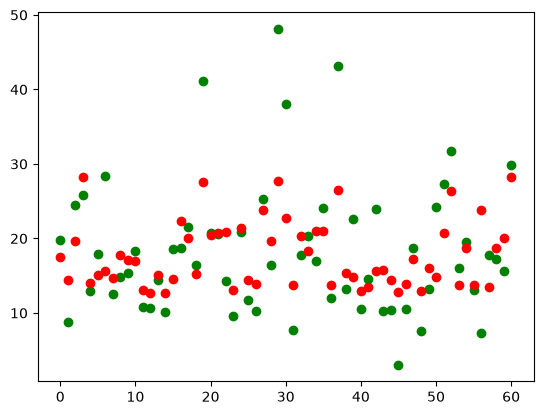

In [66]:
plt.scatter(x=range(len(y_test)),y=y_test,color="green", label="test data")
plt.scatter(x=range(len(y_pred)),y=y_pred,c="red", label="predicted data")